In [1]:


import os
import re
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl as pxl
from torch.utils.data import Dataset, DataLoader
from sklearn.ensemble import RandomForestRegressor



In [2]:
#import Excel Data

notebook_dir = os.getcwd()
file_path =os.path.join(notebook_dir,'Data','MLPARTA.xlsx')

# ── Read formulas ─────────────────────────────────────────────────────────
wb      = pxl.load_workbook(file_path)
ws      = wb.active
headers = [ws.cell(1, col).value for col in range(1, ws.max_column + 1)]

letter_to_name = {}
for col in range(1, ws.max_column + 1):
    letter = pxl.utils.get_column_letter(col)
    letter_to_name[letter] = headers[col - 1]

def excel_to_python(formula, letter_to_name):
    result = formula.lstrip('=').replace('$', '')
    result = re.sub(r'\bPI\(\)', 'np.pi', result)

    def replace_ref(match):
        letter = match.group(1)
        if letter in letter_to_name:
            return f"df['{letter_to_name[letter]}']"
        return match.group(0)

    result = re.sub(r'\b([A-Z]{1,3})(\d+)\b', replace_ref, result)

    excel_to_np = {
        'SIN'   : 'np.sin',    'COS'   : 'np.cos',    'TAN'    : 'np.tan',
        'ATAN'  : 'np.arctan', 'ATAN2' : 'np.arctan2','ASIN'   : 'np.arcsin',
        'ACOS'  : 'np.arccos', 'SQRT'  : 'np.sqrt',   'ABS'    : 'np.abs',
        'EXP'   : 'np.exp',    'LOG'   : 'np.log',    'LOG10'  : 'np.log10',
        'POWER' : 'np.power',  'MOD'   : 'np.mod',    'FLOOR'  : 'np.floor',
        'CEIL'  : 'np.ceil',   'ROUND' : 'np.round',  'MAX'    : 'np.maximum',
        'MIN'   : 'np.minimum','SUM'   : 'np.sum',
    }
    for excel_fn, np_fn in excel_to_np.items():
        result = re.sub(rf'\b{excel_fn}\b', np_fn, result)

    return result.replace('^', '**')

# ── Find formulas ─────────────────────────────────────────────────────────
formula_list = {}
for col in range(1, ws.max_column + 1):
    cell  = ws.cell(2, col)
    value = cell.value
    name  = headers[col - 1]
    if isinstance(value, str) and value.startswith('='):
        formula_list[name] = excel_to_python(value, letter_to_name)

raw_cols = [h for h in headers if h not in formula_list]

# ── Compute derived features ──────────────────────────────────────────────
def compute_features(df, formula_list):
    df         = df.copy()
    remaining  = dict(formula_list)
    max_passes = len(formula_list) + 1
    passes     = 0
    while remaining and passes < max_passes:
        passes += 1
        newly_computed = []
        for col_name, expr in remaining.items():
            try:
                df[col_name] = eval(expr)
                newly_computed.append(col_name)
            except Exception:
                pass
        for col in newly_computed:
            del remaining[col]
        if not newly_computed:
            print(f"Warning: could not resolve → {list(remaining.keys())}")
            break
    return df

wb_data    = pxl.load_workbook(file_path, data_only=True)
ws_data    = wb_data.active
data       = [row for row in ws_data.iter_rows(min_row=2, values_only=True)]
df_raw     = pd.DataFrame(data, columns=headers).dropna(how='all')
df_training = compute_features(df_raw[raw_cols], formula_list)

# ── Separate constants / features / target ────────────────────────────────
def is_constant(series, cv_threshold=0.01):
    std  = series.std()
    mean = series.mean()
    if pd.isna(std) or std == 0:    return True
    if mean == 0 or pd.isna(mean):  return std < 1e-10
    return (std / abs(mean)) < cv_threshold

target_col    = 'Power'
constant_cols = {}

for col in df_training.columns:
    if col is None:        continue
    if col == target_col:  continue
    if is_constant(df_training[col]):
        constant_cols[col] = df_training[col].iloc[0]

C = df_training[list(constant_cols.keys())].copy()
Y = df_training[[target_col]].copy()
X = df_training.drop(
        columns=list(constant_cols.keys()) + [target_col],
        errors='ignore'
    ).copy()
X = X[[col for col in X.columns if col is not None]]

# ── Convert to tensors ────────────────────────────────────────────────────
x = torch.tensor(X.values, dtype=torch.float32)   # [100, 22]
y = torch.tensor(Y.values, dtype=torch.float32).squeeze(1)   # [100]
c = torch.tensor(C.values, dtype=torch.float32)   # [100,  5]

# ── Shuffle ───────────────────────────────────────────────────────────────
torch.manual_seed(42)
shuffle_idx = torch.randperm(len(x))
x = x[shuffle_idx]
y = y[shuffle_idx]
c = c[shuffle_idx]

# ── Feature column names (needed by PINN in Step 4) ───────────────────────
feature_cols = list(X.columns)   # ['R', 'L', 'offset_e', ...]

print("=" * 55)
print("  Step 1 — Data Preparation")
print("=" * 55)
print(f"  x shape  : {x.shape}   (raw, not normalized)")
print(f"  y shape  : {y.shape}")
print(f"  c shape  : {c.shape}")
print(f"  NaN in x : {torch.isnan(x).sum().item()}")
print(f"  NaN in y : {torch.isnan(y).sum().item()}")
print(f"  NaN in c : {torch.isnan(c).sum().item()}")
print(f"  Constants: {list(constant_cols.keys())}")
print("=" * 55)



  Step 1 — Data Preparation
  x shape  : torch.Size([100, 22])   (raw, not normalized)
  y shape  : torch.Size([100])
  c shape  : torch.Size([100, 5])
  NaN in x : 0
  NaN in y : 0
  NaN in c : 0
  Constants: ['F_PB', 'Density', 'W_motor', 'Fx_s', 'Ftotal_s']


  Power Prediction Pipeline — Retry Loop + RF Distillation
  Device          : mps
  K               : 5
  Epochs          : up to 500  (patience 50)
  Batch size      : 16
  Lambda PINN     : 0.2
  Lambda RF       : 0.3
  MAE threshold   : 1.5 W
  Low MAE thresh  : 2.5 W
  R² threshold    : 0.975
  Max retries     : 3

═════════════════════════════════════════════════════════════════
  ATTEMPT 1 / 3
  Strategy  : standard stratified K-Fold
  Fold seed : 42  |  Lambda RF : 0.3
─────────────────────────────────────────────────────────────────

   Fold |    Val MAE |    Low MAE |   Val RMSE |   Val R² |  Epochs
  --------------------------------------------------------------
      1 |     2.2977 |     1.5791 |     2.9298 |   0.9700 |      66
      2 |     1.8814 |     1.5545 |     2.2867 |   0.9813 |      83
      3 |     2.0098 |     2.2568 |     2.4854 |   0.9778 |      89
      4 |     2.3318 |     2.3514 |     3.0414 |   0.9664 |     140
      5 |     2.4461 |     2.1824 |     2.7252

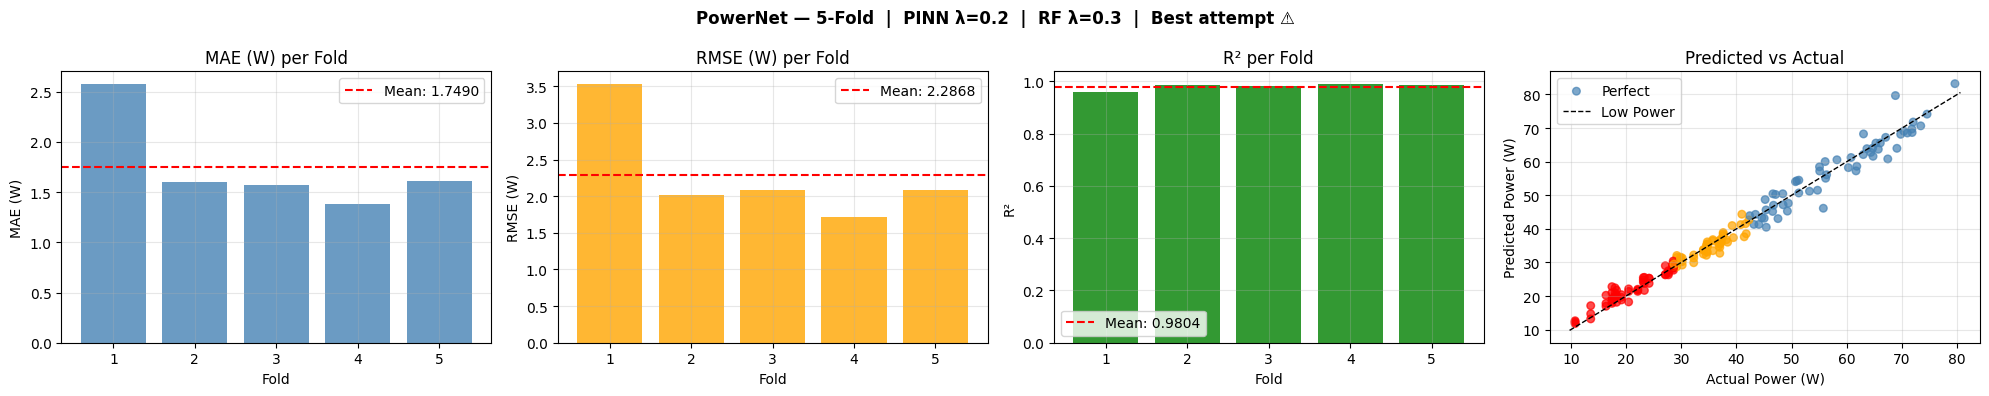

  Plot saved → power_results.png


In [ ]:



# ─────────────────────────────────────────────────────────────────────────────
# STEP 2 — DATASET CLASSES
# ─────────────────────────────────────────────────────────────────────────────

C_COLS = {name: i for i, name in enumerate(constant_cols.keys())}


class Training(Dataset):
    """
    Training dataset — 4 items per sample.
        x_mix   : Mixup'd features          → data loss
        y_mix   : Mixup'd target            → data loss
        x_orig  : original features         → PINN loss (real samples only)
        rf_pred : RF prediction (normed)    → distillation loss
    """
    def __init__(self, x_mix, y_mix, x_orig, rf_pred):
        assert x_mix.shape[0] == y_mix.shape[0] == \
               x_orig.shape[0] == rf_pred.shape[0], (
            f"Size mismatch: x_mix={x_mix.shape[0]}, y_mix={y_mix.shape[0]}, "
            f"x_orig={x_orig.shape[0]}, rf_pred={rf_pred.shape[0]}"
        )
        self.x_mix   = x_mix
        self.y_mix   = y_mix
        self.x_orig  = x_orig
        self.rf_pred = rf_pred

    def __len__(self):
        return self.x_mix.shape[0]

    def __getitem__(self, idx):
        return (
            self.x_mix[idx],
            self.y_mix[idx],
            self.x_orig[idx],
            self.rf_pred[idx],
        )

    @property
    def n_features(self):
        return self.x_mix.shape[1]

    @property
    def n_constants(self):
        return len(constant_cols)

    def __repr__(self):
        return f"Training(n={len(self)}, features={self.n_features})"


class Validation(Dataset):
    """
    Validation dataset — 3 items per sample.
        x : real normalized features
        y : real normalized target
        c : raw constants
    """
    def __init__(self, x, y, c):
        assert x.shape[0] == y.shape[0] == c.shape[0], (
            f"Size mismatch: x={x.shape[0]}, y={y.shape[0]}, c={c.shape[0]}"
        )
        self.x = x
        self.y = y
        self.c = c

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx], self.c[idx]

    @property
    def n_features(self):
        return self.x.shape[1]

    @property
    def n_constants(self):
        return self.c.shape[1]

    def __repr__(self):
        return (f"Validation(n={len(self)}, features={self.n_features}, "
                f"constants={self.n_constants})")


def get_dataloaders(train_ds, val_ds, batch_size=16, num_workers=0, seed=42):
    """
    Train : shuffled, drop_last=True  (protects BatchNorm from batch-of-1)
    Val   : ordered,  drop_last=False (every sample must be evaluated)
    """
    g = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,
        num_workers=num_workers,
        generator=g,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
        num_workers=num_workers,
    )
    return train_loader, val_loader


# ─────────────────────────────────────────────────────────────────────────────
# STEP 2.5 — STRATIFIED K-FOLD + MIXUP
# ─────────────────────────────────────────────────────────────────────────────

def skfold_idx(y, K, seed=42):

    torch.manual_seed(seed)
    sorted_idx  = torch.argsort(y)
    fold_assign = torch.zeros(len(y), dtype=torch.long)
    for rank, idx in enumerate(sorted_idx):
        fold_assign[idx] = rank % K
    fold_indices = []
    for k in range(K):
        val_idx   = (fold_assign == k).nonzero(as_tuple=True)[0]
        train_idx = (fold_assign != k).nonzero(as_tuple=True)[0]
        fold_indices.append((train_idx, val_idx))
    return fold_indices


def mixup(x, y, c, alpha=0.2, seed=42):
    """
    Beta(alpha, alpha) Mixup on training set.
    lam = max(lam, 1-lam) keeps dominant sample > 50% weight.
    Returns x_mix, y_mix, c_mix AND the lambda/permutation for RF alignment.
    """
    np.random.seed(seed)
    N     = x.size(0)
    lam   = np.random.beta(alpha, alpha, size=N)
    lam   = np.maximum(lam, 1 - lam)
    lam_t = torch.tensor(lam, dtype=torch.float32)
    idx_p = torch.randperm(N)
    lam_x = lam_t.unsqueeze(1)
    x_mix = lam_x * x + (1 - lam_x) * x[idx_p]
    y_mix = lam_t * y + (1 - lam_t) * y[idx_p]
    c_mix = lam_x * c + (1 - lam_x) * c[idx_p]
    return x_mix, y_mix, c_mix, lam_t, idx_p   # return lam + idx for RF


# ─────────────────────────────────────────────────────────────────────────────
# STEP 3 — MODEL ARCHITECTURE
# ─────────────────────────────────────────────────────────────────────────────

class Power(nn.Module):
    """
    Symmetric bottleneck MLP: input → 32 → 64 → 128 → 64 → 32 → 1
    Skip connection wraps the 64 → 128 → 64 core.
    BatchNorm + GELU + Dropout at every hidden layer.
    No _init_weights — PyTorch default + BatchNorm is sufficient.
    """
    def __init__(self, input_dim, dropout=0.1):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Linear(input_dim, 32), nn.BatchNorm1d(32), nn.GELU(), nn.Dropout(dropout),
        )
        self.block2 = nn.Sequential(
            nn.Linear(32, 64), nn.BatchNorm1d(64), nn.GELU(), nn.Dropout(dropout),
        )
        self.block3 = nn.Sequential(
            nn.Linear(64, 128), nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(dropout),
        )
        self.block4 = nn.Sequential(
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.GELU(), nn.Dropout(dropout),
        )
        self.skip_act = nn.GELU()
        self.block5 = nn.Sequential(
            nn.Linear(64, 32), nn.BatchNorm1d(32), nn.GELU(), nn.Dropout(dropout),
        )
        self.head = nn.Linear(32, 1)

    def forward(self, x):
        x   = self.block1(x)
        x   = self.block2(x)
        res = x
        x   = self.block3(x)
        x   = self.block4(x)
        x   = self.skip_act(x + res)
        x   = self.block5(x)
        return self.head(x).squeeze(1)


# ─────────────────────────────────────────────────────────────────────────────
# STEP 4 — PINN LOSS
# ─────────────────────────────────────────────────────────────────────────────

def get_constant(name):
    if name not in constant_cols:
        raise KeyError(
            f"'{name}' not found in constant_cols. "
            f"Available: {list(constant_cols.keys())}"
        )
    return constant_cols[name]


CHECK   = ['F_cl', 'Torque', 'Power']
missing = [p for p in CHECK if p not in formula_list]
if missing:
    raise ValueError(f"CHECK items missing from formula_list: {missing}")


def to_torch_expr(expr):
    return expr.replace('np.', 'torch.')


exprs = {name: to_torch_expr(formula_list[name]) for name in CHECK}

# Auto-detect which features and constants each formula needs
constant_needed = [
    name for name in constant_cols
    if any(f"df['{name}']" in expr for expr in exprs.values())
]

feat_cols = list(dict.fromkeys(
    match
    for expr in exprs.values()
    for match in re.findall(r"df\['(\w+)'\]", expr)
    if match in feature_cols
))

F_idx = {col: feature_cols.index(col) for col in feat_cols}


def physics_loss(pred_norm, x_orig, x_mean, x_std, y_mean, y_std, lambda_pinn):
    df = {}

    # Denormalize formula input features
    for col, idx in F_idx.items():
        df[col] = x_orig[:, idx] * x_std[idx] + x_mean[idx]

    # Denormalize checkpoint targets (F_cl, Torque) — outputs not inputs
    for name in CHECK:
        if name in feature_cols and name not in df:
            idx = feature_cols.index(name)
            df[name] = x_orig[:, idx] * x_std[idx] + x_mean[idx]

    # Scalar constants
    for name in constant_needed:
        df[name] = get_constant(name)

    pred_watts = pred_norm * y_std + y_mean

    Loss_1     = eval(exprs['F_cl'])
    Loss_1_mse = F.mse_loss(df['F_cl'], Loss_1)

    Loss_2     = eval(exprs['Torque'])
    Loss_2_mse = F.mse_loss(df['Torque'], Loss_2)

    Loss_3     = Loss_2 * df['W_motor']
    Loss_3_mse = F.mse_loss(pred_watts, Loss_3)

    return lambda_pinn * (Loss_1_mse + Loss_2_mse + Loss_3_mse)


# ─────────────────────────────────────────────────────────────────────────────
# STEP 4.5 — HELPER FUNCTIONS
# ─────────────────────────────────────────────────────────────────────────────

def train_epoch(model, loader, optimizer, device,
                x_mean, x_std, y_mean, y_std,
                lambda_pinn, lambda_rf):
    model.train()
    total_loss = 0.0
    criterion  = nn.MSELoss()

    for x_mix, y_mix, x_orig, rf_pred in loader:
        x_mix   = x_mix.to(device)
        y_mix   = y_mix.to(device)
        x_orig  = x_orig.to(device)
        rf_pred = rf_pred.to(device)

        optimizer.zero_grad()
        pred = model(x_mix)

        loss_data = criterion(pred, y_mix)
        loss_phys = physics_loss(
            pred, x_orig,
            x_mean.to(device), x_std.to(device),
            y_mean.to(device), y_std.to(device),
            lambda_pinn,
        )
        loss_rf   = criterion(pred, rf_pred)

        loss = loss_data + loss_phys + lambda_rf * loss_rf

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(x_mix)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    criterion  = nn.MSELoss()
    total_loss = 0.0
    all_preds, all_actuals = [], []

    for x_batch, y_batch, _ in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        pred    = model(x_batch)
        loss    = criterion(pred, y_batch)
        total_loss += loss.item() * len(x_batch)
        all_preds.append(pred.cpu())
        all_actuals.append(y_batch.cpu())

    return (
        total_loss / len(loader.dataset),
        torch.cat(all_preds),
        torch.cat(all_actuals),
    )


def tester(y_pred_norm, y_true_norm, y_mean, y_std):
    y_pred = (y_pred_norm * y_std + y_mean).numpy()
    y_true = (y_true_norm * y_std + y_mean).numpy()
    mae    = np.mean(np.abs(y_pred - y_true))
    rmse   = np.sqrt(np.mean((y_pred - y_true) ** 2))
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    r2     = 1 - ss_res / (ss_tot + 1e-8)
    return mae, rmse, r2, y_pred, y_true


def low_power_mae(y_pred_w, y_true_w, threshold_quantile=0.33):
    """MAE on bottom third of Power range (hardest region)."""
    thresh = np.quantile(y_true_w, threshold_quantile)
    mask   = y_true_w <= thresh
    if mask.sum() == 0:
        return float('inf')
    return np.mean(np.abs(y_pred_w[mask] - y_true_w[mask]))


# ─────────────────────────────────────────────────────────────────────────────
# STEP 5 — K-FOLD TRAINING LOOP (wrapped in retry)
# ─────────────────────────────────────────────────────────────────────────────

def run_kfold(fold_indices, x_data, y_data, c_data,
              epochs, patience, batch_size, device,
              lambda_pinn, lambda_rf,
              attempt_label=""):
    """
    Full K-Fold training loop.
    Returns fold results and best model state/stats.
    """
    K = len(fold_indices)

    fold_mae_list    = []
    fold_rmse_list   = []
    fold_r2_list     = []
    fold_lowmae_list = []

    best_fold_mae   = float('inf')
    best_fold_state = None
    best_fold_stats = {}

    all_preds_global  = []
    all_actuals_global = []

    print(f"\n  {'Fold':>5} | {'Val MAE':>10} | {'Low MAE':>10} | "
          f"{'Val RMSE':>10} | {'Val R²':>8} | {'Epochs':>7}")
    print(f"  {'-'*62}")

    for fold, (train_idx, val_idx) in enumerate(fold_indices):

        # ── Split ────────────────────────────────────────────────────────
        x_tr  = x_data[train_idx]
        y_tr  = y_data[train_idx]
        x_val = x_data[val_idx]
        y_val = y_data[val_idx]
        c_val = c_data[val_idx]

        # ── Normalize from train stats only ──────────────────────────────
        x_mean = x_tr.mean(dim=0)
        x_std  = x_tr.std(dim=0).clamp(min=1e-8)
        y_mean = y_tr.mean()
        y_std  = y_tr.std().clamp(min=1e-8)

        x_tr_norm  = (x_tr  - x_mean) / x_std
        x_val_norm = (x_val - x_mean) / x_std
        y_tr_norm  = (y_tr  - y_mean) / y_std
        y_val_norm = (y_val - y_mean) / y_std

        # ── RF per fold (no leakage) ──────────────────────────────────────
        rf_fold = RandomForestRegressor(n_estimators=200, random_state=42)
        rf_fold.fit(x_tr.numpy(), y_tr.numpy())

        rf_pred_tr      = torch.tensor(
            rf_fold.predict(x_tr.numpy()), dtype=torch.float32
        )
        rf_pred_tr_norm = (rf_pred_tr - y_mean) / y_std

        # ── Mixup (returns lam + idx for RF alignment) ───────────────────
        x_mix, y_mix, _, lam_t, idx_p = mixup(
            x_tr_norm, y_tr_norm, c_data[train_idx],
            alpha=0.2, seed=42+fold,
        )

        # Blend RF predictions with same lambda/permutation as x/y
        rf_mix = lam_t * rf_pred_tr_norm + (1 - lam_t) * rf_pred_tr_norm[idx_p]

        # ── Datasets & Loaders ───────────────────────────────────────────
        train_ds = Training(x_mix, y_mix, x_tr_norm, rf_mix)
        val_ds   = Validation(x_val_norm, y_val_norm, c_val)

        train_loader, val_loader = get_dataloaders(
            train_ds, val_ds, batch_size=batch_size, seed=42+fold,
        )

        # ── Fresh model per fold ─────────────────────────────────────────
        model     = Power(input_dim=x_data.shape[1]).to(device)
        optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=30, min_lr=1e-6
        )

        best_val_loss     = float('inf')
        best_state        = None
        epochs_no_improve = 0
        stopped_epoch     = epochs

        for epoch in range(1, epochs + 1):
            train_epoch(model, train_loader, optimizer, device,
                        x_mean, x_std, y_mean, y_std,
                        lambda_pinn, lambda_rf)
            val_loss, _, _ = evaluate(model, val_loader, device)
            scheduler.step(val_loss)

            if val_loss < best_val_loss:
                best_val_loss     = val_loss
                best_state        = {k: v.clone() for k, v in model.state_dict().items()}
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1

            if epochs_no_improve >= patience:
                stopped_epoch = epoch
                break

        # ── Evaluate best state ──────────────────────────────────────────
        model.load_state_dict(best_state)
        _, y_pred_norm, y_true_norm = evaluate(model, val_loader, device)

        mae, rmse, r2, y_pred_w, y_true_w = tester(
            y_pred_norm, y_true_norm, y_mean, y_std
        )
        low_mae = low_power_mae(y_pred_w, y_true_w)

        fold_mae_list.append(mae)
        fold_rmse_list.append(rmse)
        fold_r2_list.append(r2)
        fold_lowmae_list.append(low_mae)

        all_preds_global.append(y_pred_w)
        all_actuals_global.append(y_true_w)

        print(f"  {fold+1:>5} | {mae:>10.4f} | {low_mae:>10.4f} | "
              f"{rmse:>10.4f} | {r2:>8.4f} | {stopped_epoch:>7}")

        if mae < best_fold_mae:
            best_fold_mae   = mae
            best_fold_state = {k: v.clone() for k, v in model.state_dict().items()}
            best_fold_stats = {
                'x_mean' : x_mean.clone(),
                'x_std'  : x_std.clone(),
                'y_mean' : y_mean.clone(),
                'y_std'  : y_std.clone(),
            }

    results = {
        'mae_list'    : fold_mae_list,
        'rmse_list'   : fold_rmse_list,
        'r2_list'     : fold_r2_list,
        'lowmae_list' : fold_lowmae_list,
        'mean_mae'    : float(np.mean(fold_mae_list)),
        'mean_rmse'   : float(np.mean(fold_rmse_list)),
        'mean_r2'     : float(np.mean(fold_r2_list)),
        'mean_lowmae' : float(np.mean(fold_lowmae_list)),
        'best_mae'    : best_fold_mae,
        'best_state'  : best_fold_state,
        'best_stats'  : best_fold_stats,
        'all_preds'   : np.concatenate(all_preds_global),
        'all_actuals' : np.concatenate(all_actuals_global),
    }
    return results


# ─────────────────────────────────────────────────────────────────────────────
# STEP 5.5 — RETRY LOOP
# ─────────────────────────────────────────────────────────────────────────────

# ── Thresholds ────────────────────────────────────────────────────────────────
MAE_THRESHOLD     = 1.5    # W  — mean MAE across folds
LOW_MAE_THRESHOLD = 2.5    # W  — mean MAE on bottom third of Power range
R2_THRESHOLD      = 0.975  # mean R²

# ── Fixed hyperparameters ─────────────────────────────────────────────────────
K          = 5
epochs     = 500
patience   = 50
batch_size = 16

LAMBDA_PINN = 0.2
LAMBDA_RF   = 0.3

MAX_RETRIES = 3

device = torch.device(
    'mps'  if torch.backends.mps.is_available()  else
    'cuda' if torch.cuda.is_available()          else
    'cpu'
)

print("=" * 65)
print("  Power Prediction Pipeline — Retry Loop + RF Distillation")
print("=" * 65)
print(f"  Device          : {device}")
print(f"  K               : {K}")
print(f"  Epochs          : up to {epochs}  (patience {patience})")
print(f"  Batch size      : {batch_size}")
print(f"  Lambda PINN     : {LAMBDA_PINN}")
print(f"  Lambda RF       : {LAMBDA_RF}")
print(f"  MAE threshold   : {MAE_THRESHOLD} W")
print(f"  Low MAE thresh  : {LOW_MAE_THRESHOLD} W")
print(f"  R² threshold    : {R2_THRESHOLD}")
print(f"  Max retries     : {MAX_RETRIES}")
print("=" * 65)

# ── Retry strategies ──────────────────────────────────────────────────────────
#
#   Attempt 0  →  standard run
#   Attempt 1  →  new fold seed + increase LAMBDA_RF
#   Attempt 2  →  oversample low Power 2x (bottom third duplicated)
#

best_attempt_results = None
converged = False

for attempt in range(MAX_RETRIES):

    print(f"\n{'═'*65}")
    print(f"  ATTEMPT {attempt + 1} / {MAX_RETRIES}")

    # ── Per-attempt configuration ─────────────────────────────────────────
    if attempt == 0:
        fold_seed   = 42
        lam_rf      = LAMBDA_RF
        x_run, y_run, c_run = x, y, c
        strategy = "standard stratified K-Fold"

    elif attempt == 1:
        fold_seed   = 99
        lam_rf      = 0.5          # lean harder on RF guidance
        x_run, y_run, c_run = x, y, c
        strategy = "new fold seed + LAMBDA_RF=0.5"

    elif attempt == 2:
        fold_seed   = 42
        lam_rf      = 0.5
        # Oversample low Power samples (bottom third) 2×
        low_thresh  = torch.quantile(y, 0.33)
        low_mask    = y <= low_thresh
        low_idx     = low_mask.nonzero(as_tuple=True)[0]
        x_run = torch.cat([x, x[low_idx], x[low_idx]], dim=0)
        y_run = torch.cat([y, y[low_idx], y[low_idx]])
        c_run = torch.cat([c, c[low_idx], c[low_idx]], dim=0)
        strategy = f"2× oversample low Power (n={len(low_idx)} → {len(y_run)} total)"

    print(f"  Strategy  : {strategy}")
    print(f"  Fold seed : {fold_seed}  |  Lambda RF : {lam_rf}")
    print("─" * 65)

    fold_indices = skfold_idx(y_run, K, seed=fold_seed)

    results = run_kfold(
        fold_indices,
        x_run, y_run, c_run,
        epochs     = epochs,
        patience   = patience,
        batch_size = batch_size,
        device     = device,
        lambda_pinn = LAMBDA_PINN,
        lambda_rf   = lam_rf,
        attempt_label = f"attempt_{attempt+1}",
    )

    mean_mae    = results['mean_mae']
    mean_lowmae = results['mean_lowmae']
    mean_r2     = results['mean_r2']

    print(f"\n  {'─'*62}")
    print(f"  Attempt {attempt+1} summary")
    print(f"  {'─'*62}")
    print(f"  Mean MAE     : {mean_mae:.4f} W   (threshold < {MAE_THRESHOLD})")
    print(f"  Mean Low MAE : {mean_lowmae:.4f} W   (threshold < {LOW_MAE_THRESHOLD})")
    print(f"  Mean R²      : {mean_r2:.4f}    (threshold > {R2_THRESHOLD})")

    # ── Convergence check ─────────────────────────────────────────────────
    mae_ok     = mean_mae    < MAE_THRESHOLD
    lowmae_ok  = mean_lowmae < LOW_MAE_THRESHOLD
    r2_ok      = mean_r2     > R2_THRESHOLD

    if mae_ok and lowmae_ok and r2_ok:
        print(f"\n  ✓ CONVERGED on attempt {attempt+1}")
        print(f"    MAE {mean_mae:.4f} W  ✓  |  Low MAE {mean_lowmae:.4f} W  ✓  |  R² {mean_r2:.4f}  ✓")
        best_attempt_results = results
        converged = True
        break
    else:
        flags = []
        if not mae_ok:
            flags.append(f"MAE {mean_mae:.4f} ≥ {MAE_THRESHOLD}")
        if not lowmae_ok:
            flags.append(f"Low MAE {mean_lowmae:.4f} ≥ {LOW_MAE_THRESHOLD}")
        if not r2_ok:
            flags.append(f"R² {mean_r2:.4f} ≤ {R2_THRESHOLD}")
        print(f"\n  ✗ Not converged — {' | '.join(flags)}")

        # Keep best attempt by lowest mean MAE even if not converged
        if best_attempt_results is None or mean_mae < best_attempt_results['mean_mae']:
            best_attempt_results = results
            print(f"    → New best attempt saved (MAE {mean_mae:.4f} W)")

        if attempt < MAX_RETRIES - 1:
            print(f"  → Retrying with attempt {attempt+2} strategy...")

if not converged:
    print(f"\n  ⚠ Did not converge in {MAX_RETRIES} attempts.")
    print(f"  → Using best attempt: MAE {best_attempt_results['mean_mae']:.4f} W")


# ─────────────────────────────────────────────────────────────────────────────
# STEP 6 — RESULTS, SAVE & INFERENCE
# ─────────────────────────────────────────────────────────────────────────────

res = best_attempt_results

print(f"\n{'='*65}")
print(f"  Final Cross-Validation Results")
print(f"{'='*65}")
print(f"  {'Fold':>5}  {'MAE':>8}  {'Low MAE':>10}  {'RMSE':>8}  {'R²':>8}")
print(f"  {'-'*50}")
for i, (m, lm, r, r2) in enumerate(zip(
        res['mae_list'], res['lowmae_list'],
        res['rmse_list'], res['r2_list'])):
    print(f"  {i+1:>5}  {m:>8.4f}  {lm:>10.4f}  {r:>8.4f}  {r2:>8.4f}")
print(f"  {'-'*50}")
print(f"  {'Mean':>5}  {res['mean_mae']:>8.4f}  {res['mean_lowmae']:>10.4f}"
      f"  {res['mean_rmse']:>8.4f}  {res['mean_r2']:>8.4f}")
print(f"  {'Std':>5}  {np.std(res['mae_list']):>8.4f}  "
      f"{np.std(res['lowmae_list']):>10.4f}  "
      f"{np.std(res['rmse_list']):>8.4f}  "
      f"{np.std(res['r2_list']):>8.4f}")
print(f"{'='*65}")
print(f"  Best fold MAE : {res['best_mae']:.4f} W")

# ── Save ──────────────────────────────────────────────────────────────────────
torch.save({
    'model_state_dict' : res['best_state'],
    'x_mean'           : res['best_stats']['x_mean'],
    'x_std'            : res['best_stats']['x_std'],
    'y_mean'           : res['best_stats']['y_mean'],
    'y_std'            : res['best_stats']['y_std'],
    'feature_cols'     : feature_cols,
    'input_dim'        : x.shape[1],
    'C_COLS'           : C_COLS,
    'converged'        : converged,
    'final_mae'        : res['mean_mae'],
    'final_low_mae'    : res['mean_lowmae'],
    'final_r2'         : res['mean_r2'],
}, 'power_model_best.pt')
print(f"\n  Model saved → power_model_best.pt")

# ── Inference ────────────────────────────────────────────────────────────────
def predict_power(feature_dict):
    """
    Predict Power (W) for a single new sample.
    feature_dict: {col_name: value} for all feature columns.
    """
    checkpoint = torch.load('power_model_best.pt', weights_only=False)
    net = Power(input_dim=checkpoint['input_dim'])
    net.load_state_dict(checkpoint['model_state_dict'])
    net.eval()

    cols   = checkpoint['feature_cols']
    xm, xs = checkpoint['x_mean'], checkpoint['x_std']
    ym, ys = checkpoint['y_mean'], checkpoint['y_std']

    x_raw = torch.tensor([[feature_dict[c] for c in cols]], dtype=torch.float32)
    x_n   = (x_raw - xm) / xs
    with torch.no_grad():
        pred_n = net(x_n)
    return (pred_n * ys + ym).item()


# ── Plots ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle(
    f"PowerNet — {K}-Fold  |  PINN λ={LAMBDA_PINN}  |  RF λ={LAMBDA_RF}  |  "
    f"{'Converged ✓' if converged else 'Best attempt ⚠'}",
    fontweight='bold'
)
folds_x = range(1, K + 1)

for ax, vals, label, color in zip(
    axes[:3],
    [res['mae_list'], res['rmse_list'], res['r2_list']],
    ['MAE (W)', 'RMSE (W)', 'R²'],
    ['steelblue', 'orange', 'green'],
):
    ax.bar(folds_x, vals, color=color, alpha=0.8)
    ax.axhline(np.mean(vals), color='red', linestyle='--',
               label=f'Mean: {np.mean(vals):.4f}')
    ax.set_title(f'{label} per Fold')
    ax.set_xlabel('Fold')
    ax.set_ylabel(label)
    ax.legend()
    ax.grid(True, alpha=0.3)

# Predicted vs Actual
ax = axes[3]
y_pred_all   = res['all_preds']
y_actual_all = res['all_actuals']
low_thresh   = np.quantile(y_actual_all, 0.33)
mid_thresh   = np.quantile(y_actual_all, 0.66)

colors_pt = np.where(y_actual_all <= low_thresh, 'red',
            np.where(y_actual_all <= mid_thresh, 'orange', 'steelblue'))

ax.scatter(y_actual_all, y_pred_all, c=colors_pt, alpha=0.7, s=30)
lims = [y_actual_all.min() - 1, y_actual_all.max() + 1]
ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect')
ax.set_title('Predicted vs Actual')
ax.set_xlabel('Actual Power (W)')
ax.set_ylabel('Predicted Power (W)')
ax.legend(['Perfect', 'Low Power', 'Mid Power', 'High Power'])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('power_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Plot saved → power_results.png")